<a href="https://colab.research.google.com/github/tse-code/ML-AI-Projects/blob/main/Netflix_Title_Classification_Predicting_Movies_and_TV_Shows_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
# Cell 1: Imports and Drive Mount
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# Cell 2: Load Dataset
csv_path = "/content/drive/MyDrive/Netflix Classification/netflix_titles.csv"  # Adjust path as necessary
df = pd.read_csv(csv_path)

print("[INFO] Dataset Loaded. Shape:", df.shape)
print("[INFO] Columns:", df.columns)
print(df.head(5))  # Display the first few rows


[INFO] Dataset Loaded. Shape: (8807, 12)
[INFO] Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan R

In [59]:
# Cell 3: Preprocessing
def preprocess_data(df):
    # 1. Handle missing values in critical columns
    df = df.dropna(subset=['type', 'description'])  # Remove rows without 'type' or 'description'
    df['country'] = df['country'].fillna('Unknown')  # Replace missing countries with 'Unknown'

    # 2. Parse duration: Extract numeric values
    def parse_duration(row):
        if pd.isna(row):
            return 0
        match = re.findall(r'(\d+)', str(row))
        return int(match[0]) if match else 0

    df['parsed_duration'] = df['duration'].apply(parse_duration)

    # 3. Add additional features
    df['desc_length'] = df['description'].apply(lambda x: len(x.split()))  # Description word count
    df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown')

    print("[INFO] Preprocessing complete. Shape:", df.shape)
    return df

df = preprocess_data(df)
print(df[['type', 'parsed_duration', 'desc_length', 'main_country']].head())


[INFO] Preprocessing complete. Shape: (8807, 15)
      type  parsed_duration  desc_length   main_country
0    Movie               90           27  United States
1  TV Show                2           27   South Africa
2  TV Show                1           27        Unknown
3  TV Show                1           24        Unknown
4  TV Show                2           24          India


In [82]:
# Feature engineering without `parsed_duration`
def feature_engineering_no_duration(df):
    # 1. TF-IDF for descriptions
    tfidf = TfidfVectorizer(stop_words='english', max_features=300)
    tfidf_matrix = tfidf.fit_transform(df['description'])
    tfidf_cols = [f"tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)

    # 2. Multi-label binarization for 'listed_in'
    def split_genres(s):
        return [g.strip() for g in str(s).split(',')] if pd.notna(s) else []

    # Handle missing 'listed_in'
    df['listed_in'] = df['listed_in'].fillna('Unknown')  # Replace NaN with 'Unknown'

    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(df['listed_in'].apply(split_genres))
    genre_cols = [f"genre_{g}" for g in mlb.classes_]
    genre_df = pd.DataFrame(genre_matrix, columns=genre_cols, index=df.index)

    # 3. One-hot encoding for 'main_country' (top 10 countries)
    top_10_countries = df['main_country'].value_counts().head(10).index
    df['main_country_limited'] = df['main_country'].apply(lambda c: c if c in top_10_countries else 'Other')
    country_dummies = pd.get_dummies(df['main_country_limited'], prefix="country")

    # Combine features
    final_df = pd.concat([df[['desc_length']], tfidf_df, genre_df, country_dummies], axis=1)  # Exclude `parsed_duration`
    print("[INFO] Feature engineering (no duration) complete. Shape:", final_df.shape)
    return final_df, genre_cols


In [83]:
# Cell 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("[INFO] Training set shape:", X_train.shape)
print("[INFO] Test set shape:", X_test.shape)


[INFO] Training set shape: (7045, 355)
[INFO] Test set shape: (1762, 355)


In [84]:
# Cell 6: Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1.0, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

logreg = LogisticRegression(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logreg_search = RandomizedSearchCV(logreg, param_distributions=param_grid, scoring='f1_macro', cv=cv, n_iter=10, random_state=42)
logreg_search.fit(X_train, y_train)

# Evaluate
y_pred_logreg = logreg_search.best_estimator_.predict(X_test)
acc = accuracy_score(y_test, y_pred_logreg)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_logreg, average='macro')
print("[Logistic Regression] Final Metrics:")
print(f"  Accuracy:  {acc:.3f}")
print(f"  Precision: {prec:.3f}")
print(f"  Recall:    {rec:.3f}")
print(f"  F1-score:  {f1:.3f}")


[Logistic Regression] Final Metrics:
  Accuracy:  1.000
  Precision: 1.000
  Recall:    1.000
  F1-score:  1.000


In [85]:
# Cell 7: Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf, param_distributions=param_grid_rf, scoring='f1_macro', cv=cv, n_iter=10, random_state=42)
rf_search.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_search.best_estimator_.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')
print("[Random Forest] Final Metrics:")
print(f"  Accuracy:  {acc_rf:.3f}")
print(f"  Precision: {prec_rf:.3f}")
print(f"  Recall:    {rec_rf:.3f}")
print(f"  F1-score:  {f1_rf:.3f}")


[Random Forest] Final Metrics:
  Accuracy:  0.999
  Precision: 1.000
  Recall:    0.999
  F1-score:  0.999


<Figure size 1000x600 with 0 Axes>

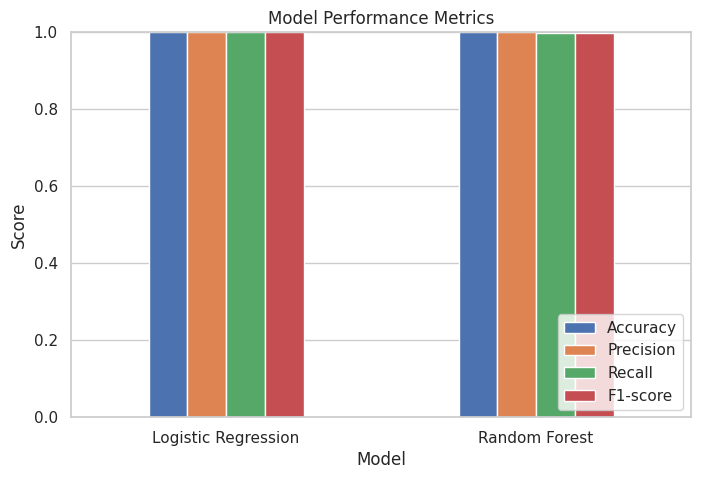

In [78]:
# Cell 8: Plot Metrics
metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc, acc_rf],
    'Precision': [prec, prec_rf],
    'Recall': [rec, rec_rf],
    'F1-score': [f1, f1_rf]
})

plt.figure(figsize=(10, 6))
metrics.set_index('Model').plot(kind='bar', rot=0)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()


In [65]:
#Checking for data leakage
print(df.groupby('type')['parsed_duration'].describe())


          count       mean        std  min   25%   50%    75%    max
type                                                                
Movie    6131.0  99.528462  28.369284  0.0  87.0  98.0  114.0  312.0
TV Show  2676.0   1.764948   1.582752  1.0   1.0   1.0    2.0   17.0


In [79]:
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(random_state=42, C=1, solver='lbfgs', max_iter=200)
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=None, min_samples_split=10)

logreg_scores = cross_val_score(logreg, X, y, cv=5, scoring='f1_macro')
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='f1_macro')

print("[Nested CV] Logistic Regression F1:", logreg_scores.mean())
print("[Nested CV] Random Forest F1:", rf_scores.mean())


[Nested CV] Logistic Regression F1: 0.9987935095624912
[Nested CV] Random Forest F1: 0.9995976630926743


In [81]:
print("[DEBUG] Sample values from 'listed_in':")
print(df['listed_in'].head(10))


[DEBUG] Sample values from 'listed_in':
0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: object


In [89]:
# After feature engineering
X, genre_cols = feature_engineering_no_duration(df)

# Debug: Check the genre columns
print("[DEBUG] Genre columns created:", genre_cols)

# Debug: Check if the genre columns exist in the DataFrame
print("[DEBUG] All columns in the DataFrame:", X.columns.tolist())


[INFO] Feature engineering (no duration) complete. Shape: (8807, 354)
[DEBUG] Genre columns created: ['genre_Action & Adventure', 'genre_Anime Features', 'genre_Anime Series', 'genre_British TV Shows', 'genre_Children & Family Movies', 'genre_Classic & Cult TV', 'genre_Classic Movies', 'genre_Comedies', 'genre_Crime TV Shows', 'genre_Cult Movies', 'genre_Documentaries', 'genre_Docuseries', 'genre_Dramas', 'genre_Faith & Spirituality', 'genre_Horror Movies', 'genre_Independent Movies', 'genre_International Movies', 'genre_International TV Shows', "genre_Kids' TV", 'genre_Korean TV Shows', 'genre_LGBTQ Movies', 'genre_Movies', 'genre_Music & Musicals', 'genre_Reality TV', 'genre_Romantic Movies', 'genre_Romantic TV Shows', 'genre_Sci-Fi & Fantasy', 'genre_Science & Nature TV', 'genre_Spanish-Language TV Shows', 'genre_Sports Movies', 'genre_Stand-Up Comedy', 'genre_Stand-Up Comedy & Talk Shows', 'genre_TV Action & Adventure', 'genre_TV Comedies', 'genre_TV Dramas', 'genre_TV Horror', 'ge

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate Metrics
def evaluate_model(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    print(f"[{model_name}] Metrics:")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-score:  {f1:.3f}")

evaluate_model(y_test, y_pred_logreg, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


[Logistic Regression] Metrics:
  Accuracy:  1.000
  Precision: 1.000
  Recall:    1.000
  F1-score:  1.000
[Random Forest] Metrics:
  Accuracy:  1.000
  Precision: 1.000
  Recall:    1.000
  F1-score:  1.000


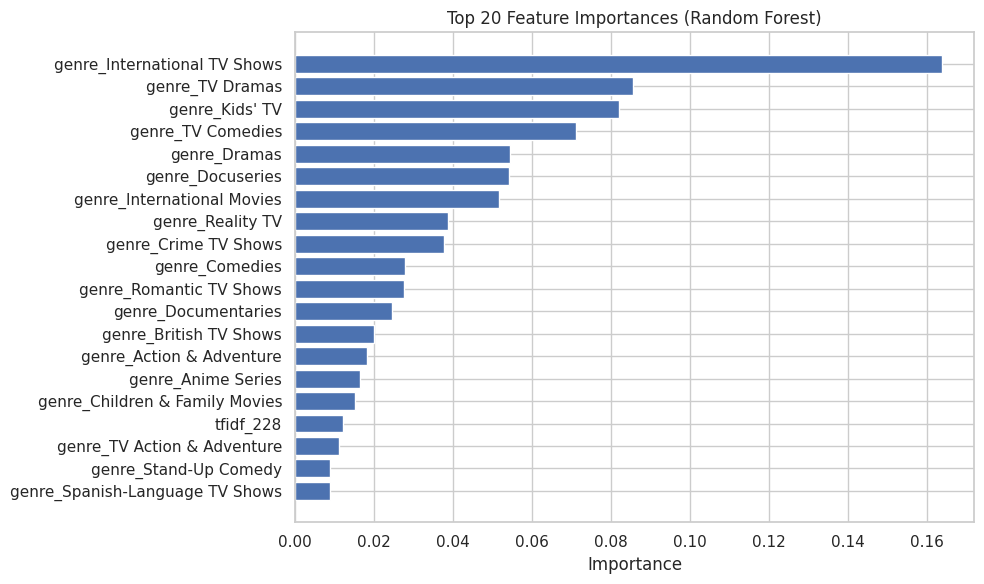

In [92]:
import numpy as np

# Get feature importances from Random Forest
importances = rf.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx][:20][::-1], importances[sorted_idx][:20][::-1])
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [93]:
# Feature engineering call
X, genre_cols = feature_engineering_no_duration(df)

# Check columns in X to ensure genres exist
print("[DEBUG] Columns in X:", X.columns.tolist())


[INFO] Feature engineering (no duration) complete. Shape: (8807, 354)
[DEBUG] Columns in X: ['desc_length', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', 'tfidf_50', 'tfidf_51', 'tfidf_52', 'tfidf_53', 'tfidf_54', 'tfidf_55', 'tfidf_56', 'tfidf_57', 'tfidf_58', 'tfidf_59', 'tfidf_60', 'tfidf_61', 'tfidf_62', 'tfidf_63', 'tfidf_64', 'tfidf_65', 'tfidf_66', 'tfidf_67', 'tfidf_68', 'tfidf_69', 'tfidf_70', 'tfidf_71', 'tfidf_72', 'tfidf_73', 'tfidf_74', 't

In [94]:
# Group and sum genres using X (feature matrix)
genre_sums = pd.DataFrame({
    'Movie': X[y == 0][genre_cols].sum(),
    'TV Show': X[y == 1][genre_cols].sum()
}).T


<ipython-input-95-40e47d8321a7>:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


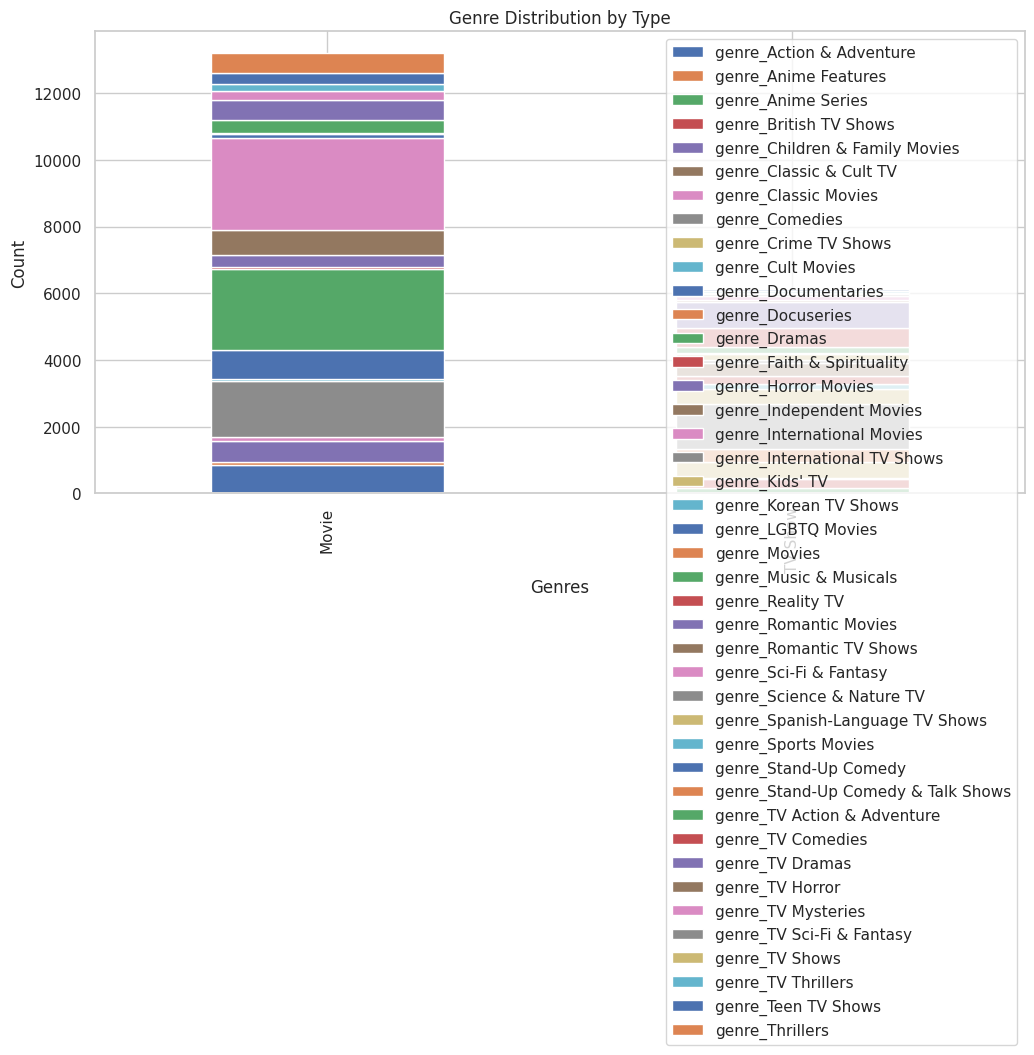

In [95]:
# Plot genre distribution by type
genre_sums.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Genre Distribution by Type')
plt.ylabel('Count')
plt.xlabel('Genres')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


[INFO] Feature engineering (no duration) complete. Shape: (8807, 354)


<ipython-input-96-61ab0cb2fc3e>:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


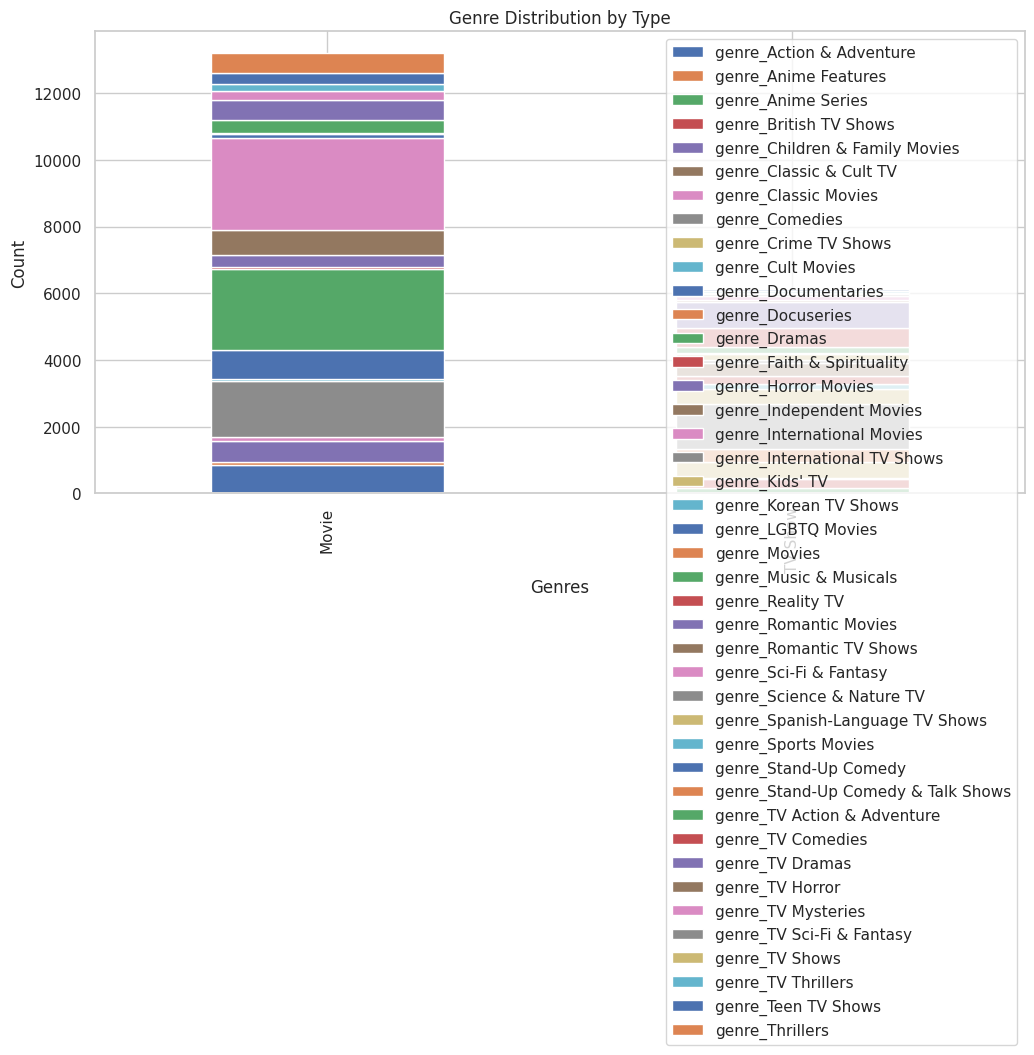

In [96]:
# Feature engineering
X, genre_cols = feature_engineering_no_duration(df)

# Compute genre counts
genre_sums = pd.DataFrame({
    'Movie': X[y == 0][genre_cols].sum(),
    'TV Show': X[y == 1][genre_cols].sum()
}).T

# Plot genre distribution
genre_sums.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Genre Distribution by Type')
plt.ylabel('Count')
plt.xlabel('Genres')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
